In [1]:
import json
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

INPUT_SIZE = 28 * 28 
NUM_CLASSES = 10
BATCH_SIZE = 500 
EPOCHS = 5         
SEED = 42          

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='../data', train=True, transform=transform, download=False)
test_dataset = datasets.MNIST(root='../data', train=False, transform=transform, download=False)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class LogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

## SGD

In [2]:
# --- Loss Function ---
criterion = nn.MSELoss()
all_loss_histories = {}

# --- Learning Rates ---
LEARNING_RATES = [3.0, 2.0, 1.0, 0.5, 0.3, 0.1, 0.05, 0.03, 0.01]

for lr in LEARNING_RATES:
    print(f"--- Starting Training for Learning Rate: {lr} ---")
    torch.manual_seed(SEED)
    model = LogisticRegression(INPUT_SIZE, NUM_CLASSES)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            logits = model(data)
            output_probs = torch.softmax(logits, dim=1)
            target_one_hot = nn.functional.one_hot(target, num_classes=NUM_CLASSES).float()
            loss = criterion(output_probs, target_one_hot)
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())
        
        print(f"LR: {lr}, Epoch [{epoch+1}/{EPOCHS}], Final Batch Loss: {loss.item():.5f}")

    # Update loss history
    all_loss_histories[lr] = loss_history

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    print(f"Final Accuracy for LR {lr}: {100 * correct / total:.2f}%\n")

with open("results/mse_sgd.json", "w") as f:
    json.dump(all_loss_histories, f)

--- Starting Training for Learning Rate: 3.0 ---
LR: 3.0, Epoch [1/5], Final Batch Loss: 0.01602
LR: 3.0, Epoch [2/5], Final Batch Loss: 0.01277
LR: 3.0, Epoch [3/5], Final Batch Loss: 0.01125
LR: 3.0, Epoch [4/5], Final Batch Loss: 0.01071
LR: 3.0, Epoch [5/5], Final Batch Loss: 0.00911
Final Accuracy for LR 3.0: 92.74%

--- Starting Training for Learning Rate: 2.0 ---
LR: 2.0, Epoch [1/5], Final Batch Loss: 0.01606
LR: 2.0, Epoch [2/5], Final Batch Loss: 0.01284
LR: 2.0, Epoch [3/5], Final Batch Loss: 0.01139
LR: 2.0, Epoch [4/5], Final Batch Loss: 0.01073
LR: 2.0, Epoch [5/5], Final Batch Loss: 0.00953
Final Accuracy for LR 2.0: 92.33%

--- Starting Training for Learning Rate: 1.0 ---
LR: 1.0, Epoch [1/5], Final Batch Loss: 0.01752
LR: 1.0, Epoch [2/5], Final Batch Loss: 0.01382
LR: 1.0, Epoch [3/5], Final Batch Loss: 0.01199
LR: 1.0, Epoch [4/5], Final Batch Loss: 0.01133
LR: 1.0, Epoch [5/5], Final Batch Loss: 0.01072
Final Accuracy for LR 1.0: 92.09%

--- Starting Training for Le

## ADAM

In [3]:
LEARNING_RATES = [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
criterion = nn.MSELoss()
all_loss_histories = {}

for lr in LEARNING_RATES:
    print(f"--- Starting Training for Adam with Learning Rate: {lr} ---")
    torch.manual_seed(SEED)
    model = LogisticRegression(INPUT_SIZE, NUM_CLASSES)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            logits = model(data)
            output_probs = torch.softmax(logits, dim=1)
            target_one_hot = nn.functional.one_hot(target, num_classes=NUM_CLASSES).float()
            loss = criterion(output_probs, target_one_hot)
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_history.append(loss.item())
        
        print(f"LR: {lr}, Epoch [{epoch+1}/{EPOCHS}], Final Batch Loss: {loss.item():.5f}")

    all_loss_histories[lr] = loss_history

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    print(f"Final Accuracy for LR {lr}: {100 * correct / total:.2f}%\n")


with open("results/mse_adam.json", "w") as f:
    json.dump(all_loss_histories, f) 
# plt.ylim(0, 0.05)

--- Starting Training for Adam with Learning Rate: 0.5 ---
LR: 0.5, Epoch [1/5], Final Batch Loss: 0.09037
LR: 0.5, Epoch [2/5], Final Batch Loss: 0.10090
LR: 0.5, Epoch [3/5], Final Batch Loss: 0.10112
LR: 0.5, Epoch [4/5], Final Batch Loss: 0.09115
LR: 0.5, Epoch [5/5], Final Batch Loss: 0.09800
Final Accuracy for LR 0.5: 53.15%

--- Starting Training for Adam with Learning Rate: 0.1 ---
LR: 0.1, Epoch [1/5], Final Batch Loss: 0.05390
LR: 0.1, Epoch [2/5], Final Batch Loss: 0.05390
LR: 0.1, Epoch [3/5], Final Batch Loss: 0.05332
LR: 0.1, Epoch [4/5], Final Batch Loss: 0.04770
LR: 0.1, Epoch [5/5], Final Batch Loss: 0.04871
Final Accuracy for LR 0.1: 73.78%

--- Starting Training for Adam with Learning Rate: 0.05 ---
LR: 0.05, Epoch [1/5], Final Batch Loss: 0.05156
LR: 0.05, Epoch [2/5], Final Batch Loss: 0.05078
LR: 0.05, Epoch [3/5], Final Batch Loss: 0.04874
LR: 0.05, Epoch [4/5], Final Batch Loss: 0.04583
LR: 0.05, Epoch [5/5], Final Batch Loss: 0.04572
Final Accuracy for LR 0.05:

## OLNM

In [6]:
import sys, os
sys.path.append(os.path.abspath('..'))
from olnm import OLNM

In [11]:
criterion = nn.MSELoss()
all_loss_histories = {}

LEARNING_RATES = [3.0, 2.0, 1.0, 0.5, 0.1, 0.05]
for lr in LEARNING_RATES:
    print(f"--- Starting Training for OLNM with Learning Rate: {lr} ---")
    torch.manual_seed(SEED)
    model = LogisticRegression(INPUT_SIZE, NUM_CLASSES)
    optimizer = OLNM(model.parameters(), 
                              lr=lr, 
                              T=50, 
                              batch_size=BATCH_SIZE,
                              )

    loss_history = []
    
    for epoch in range(EPOCHS):
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            def closure(grad=True):
                logits = model(data)
                output_probs = torch.softmax(logits, dim=1)
                target_one_hot = nn.functional.one_hot(target, num_classes=NUM_CLASSES).float()
                loss = criterion(output_probs, target_one_hot)
                if grad:
                    optimizer.zero_grad()
                    loss.backward()
                return loss
            loss = optimizer.step(closure)

            loss_history.append(loss.item())
        
        print(f"LR: {lr}, Epoch [{epoch+1}/{EPOCHS}], Final Batch Loss: {loss.item():.5f}")

    all_loss_histories[lr] = loss_history

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    print(f"Final Accuracy for LR {lr}: {100 * correct / total:.2f}%\n")

with open("results/mse_olnm.json", "w") as f:
    json.dump(all_loss_histories, f) 

# plt.ylim(0, 0.1)

--- Starting Training for OLNM with Learning Rate: 3.0 ---
LR: 3.0, Epoch [1/5], Final Batch Loss: 0.03790
LR: 3.0, Epoch [2/5], Final Batch Loss: 0.03678
LR: 3.0, Epoch [3/5], Final Batch Loss: 0.03420
LR: 3.0, Epoch [4/5], Final Batch Loss: 0.03410
LR: 3.0, Epoch [5/5], Final Batch Loss: 0.03368
Final Accuracy for LR 3.0: 75.03%

--- Starting Training for OLNM with Learning Rate: 2.0 ---
LR: 2.0, Epoch [1/5], Final Batch Loss: 0.02663
LR: 2.0, Epoch [2/5], Final Batch Loss: 0.02598
LR: 2.0, Epoch [3/5], Final Batch Loss: 0.02241
LR: 2.0, Epoch [4/5], Final Batch Loss: 0.02391
LR: 2.0, Epoch [5/5], Final Batch Loss: 0.02042
Final Accuracy for LR 2.0: 83.92%

--- Starting Training for OLNM with Learning Rate: 1.0 ---
LR: 1.0, Epoch [1/5], Final Batch Loss: 0.01442
LR: 1.0, Epoch [2/5], Final Batch Loss: 0.01150
LR: 1.0, Epoch [3/5], Final Batch Loss: 0.01034
LR: 1.0, Epoch [4/5], Final Batch Loss: 0.01045
LR: 1.0, Epoch [5/5], Final Batch Loss: 0.00914
Final Accuracy for LR 1.0: 92.52%

## Visualization

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("results/mse_olnm.json", "r") as f:
    olnm_histories = json.load(f)
with open("results/mse_sgd.json", "r") as f:
    sgd_histories = json.load(f)
with open("results/mse_adam.json", "r") as f:
    adam_histories = json.load(f)

In [9]:
# --- Plotting ---
def plot_histories(histories, title, filename):
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(8, 6))
    for lr, history in histories.items():
        window_size = 10
        smoothed_history = np.convolve(history, np.ones(window_size)/window_size, mode='valid')
        plt.plot(smoothed_history, 
                 label=f'{lr}',
                 linewidth=2,
                #  markevery=50, 
                #  marker='*',
                 )
    # plt.title(title, fontsize=16)
    plt.xlabel('Iteration', fontsize=16)
    plt.xticks(fontsize=16)
    plt.ylabel('MSE', fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(title=f'{title} Learning Rate', fontsize=16)
    plt.grid(True, alpha=0.5)
    # plt.ylim(0, 2)
    plt.savefig(f"imgs/png/{filename}.png")
    plt.savefig(f"imgs/pdf/{filename}.pdf", bbox_inches='tight')
    plt.savefig(f"imgs/svg/{filename}.svg", bbox_inches='tight')
    plt.show()

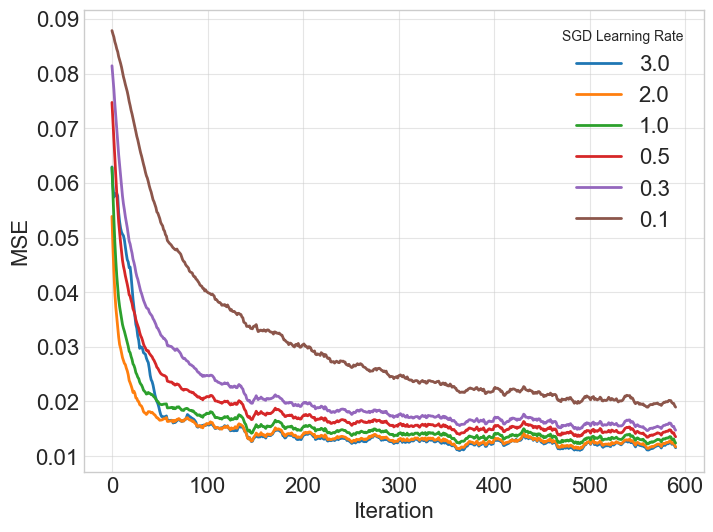

In [13]:
plot_histories(sgd_histories, 'SGD', 'tuning_mse_sgd')

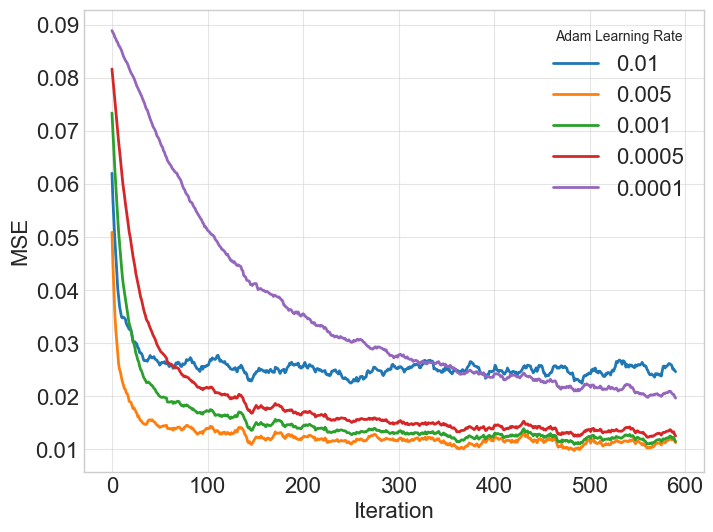

In [14]:
plot_histories(adam_histories, 'Adam', 'tuning_mse_adam')

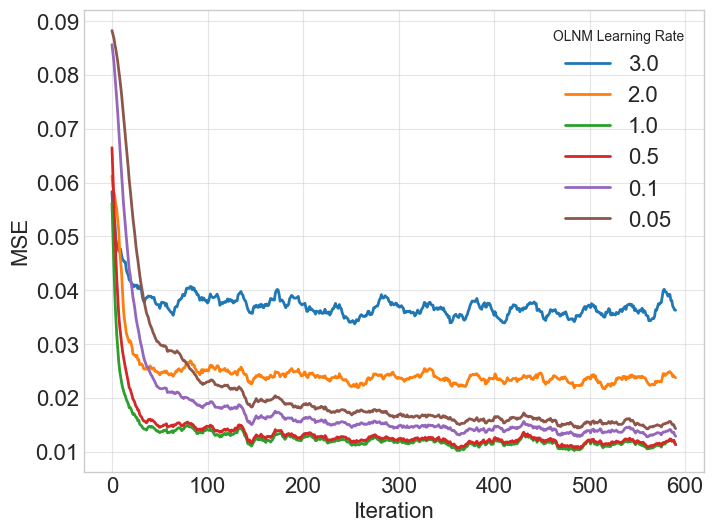

In [13]:
plot_histories(olnm_histories, 'OLNM', 'tuning_mse_olnm')